# NOTEBOOK 3: DESPLIEGUE CON INTERFAZ GRÁFICA
**Modelo:** Random Forest Optimizado (GridSearchCV)  
**Objetivo:** Predecir si un caso de delito informático involucra criminalidad organizada  
**Interfaz:** Gradio (interfaz web interactiva)

## 0. Instalación e importación

In [ ]:
# Instalar Gradio (interfaz gráfica web)
import sys
import subprocess

# Limpiar caché y reinstalar
subprocess.run([sys.executable, "-m", "pip", "cache", "purge"], capture_output=True)
subprocess.run([sys.executable, "-m", "pip", "install", "--upgrade", "pip", "setuptools", "wheel"], 
               capture_output=True)

result = subprocess.run(
    [sys.executable, "-m", "pip", "install", "gradio", "--upgrade", "--no-cache-dir"],
    capture_output=True,
    text=True
)

if result.returncode == 0:
    print("Gradio instalado correctamente")
else:
    print("Advertencia:", result.stderr[:200])

Gradio instalado correctamente


In [3]:
import gradio as gr
import pandas as pd
import numpy as np
import joblib
import warnings
warnings.filterwarnings('ignore')

print(f'Gradio versión: {gr.__version__}')

c:\Users\Julián\AppData\Local\Programs\Python\Python312\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Gradio versión: 6.14.0


## 1. CARGA DEL MODELO Y COMPONENTES

In [4]:
# Cargar todos los artefactos guardados en el Notebook 2
modelo   = joblib.load('modelos/modelo_final.pkl')
scaler   = joblib.load('modelos/scaler.pkl')
encoders = joblib.load('modelos/encoders.pkl')
le_target = joblib.load('modelos/le_target.pkl')
FEATURES  = joblib.load('modelos/features.pkl')

print('Modelo y artefactos cargados correctamente')
print(f'   Modelo:   {type(modelo).__name__}')
print(f'   Features: {FEATURES}')

Modelo y artefactos cargados correctamente
   Modelo:   RandomForestClassifier
   Features: ['ES_ARCHIVO', 'ES_PRECLUSION', 'ESTADO', 'ETAPA_CASO', 'LEY', 'PAIS_HECHO', 'DEPARTAMENTO_HECHO', 'ANO_HECHOS', 'ANO_ENTRADA', 'TOTAL_PROCESOS', 'PERIODO_HECHO']


## 2. FUNCIÓN DE PREDICCIÓN

In [5]:
def predecir_criminalidad(
    es_archivo,
    es_preclusion,
    estado,
    etapa_caso,
    ley,
    pais_hecho,
    departamento_hecho,
    ano_hechos,
    ano_entrada,
    total_procesos,
    periodo_hecho
):
    """
    Recibe los parámetros del caso y retorna la predicción
    de criminalidad organizada con probabilidad.
    """
    # Construir el registro como DataFrame
    datos = {
        'ES_ARCHIVO':          [es_archivo],
        'ES_PRECLUSION':       [es_preclusion],
        'ESTADO':              [estado],
        'ETAPA_CASO':          [etapa_caso],
        'LEY':                 [ley],
        'PAIS_HECHO':          [pais_hecho],
        'DEPARTAMENTO_HECHO':  [departamento_hecho],
        'ANO_HECHOS':          [int(ano_hechos)],
        'ANO_ENTRADA':         [int(ano_entrada)],
        'TOTAL_PROCESOS':      [int(total_procesos)],
        'PERIODO_HECHO':       [periodo_hecho],
    }
    df_input = pd.DataFrame(datos)

    # Aplicar encoders a columnas categóricas
    for col in df_input.select_dtypes(include='object').columns:
        if col in encoders:
            le = encoders[col]
            # Manejar valores no vistos durante el entrenamiento
            val = df_input[col].values[0]
            if val in le.classes_:
                df_input[col] = le.transform([val])
            else:
                df_input[col] = 0  # Valor por defecto

    # Seleccionar solo las features del modelo
    X_input = df_input[FEATURES]

    # Predecir
    prediccion = modelo.predict(X_input)[0]
    probabilidades = modelo.predict_proba(X_input)[0]

    # Decodificar resultado
    etiqueta = le_target.inverse_transform([prediccion])[0]  # 'SI' o 'NO'
    prob_si = probabilidades[1] * 100
    prob_no = probabilidades[0] * 100

    # Construir respuesta
    if etiqueta == 'SI':
        resultado = f'CRIMINALIDAD ORGANIZADA: SÍ'
        detalle = f'Este caso presenta indicadores de criminalidad organizada.\n'
        nivel = 'ALTO RIESGO' if prob_si > 80 else 'RIESGO MODERADO'
    else:
        resultado = f'CRIMINALIDAD ORGANIZADA: NO'
        detalle = f'Este caso no presenta indicadores de criminalidad organizada.\n'
        nivel = 'BAJO RIESGO'

    probabilidad_texto = (
        f'{nivel}\n\n'
        f'Probabilidad de SÍ (criminalidad): {prob_si:.1f}%\n'
        f'Probabilidad de NO:                {prob_no:.1f}%\n\n'
        f'{detalle}'
        f'Modelo: Random Forest Optimizado (GridSearchCV)'
    )

    return resultado, probabilidad_texto


print('Función de predicción definida')

Función de predicción definida


## 3. INTERFAZ GRÁFICA CON GRADIO

In [6]:
# Opciones para los selectores
OPCIONES_SI_NO  = ['SI', 'NO']
OPCIONES_ESTADO = ['ACTIVO', 'INACTIVO']
OPCIONES_ETAPA  = ['INDAGACIÓN', 'INVESTIGACIÓN', 'JUICIO',
                   'EJECUCIÓN DE PENAS', 'TERMINACIÓN ANTICIPADA']
OPCIONES_LEY    = ['LEY 906', 'LEY 1098', 'JURISDICCIÓN MENORES']
OPCIONES_PAIS   = ['COLOMBIA', 'SIN DATO']
OPCIONES_DPTO   = [
    'ANTIOQUIA', 'BOGOTÁ, D. C.', 'VALLE DEL CAUCA', 'SANTANDER',
    'CUNDINAMARCA', 'ATLÁNTICO', 'BOLÍVAR', 'NARIÑO', 'CÓRDOBA',
    'HUILA', 'TOLIMA', 'CAUCA', 'BOYACA', 'META', 'RISARALDA',
    'CALDAS', 'NORTE DE SANTANDER', 'MAGDALENA', 'CESAR', 'QUINDÍO',
    'LA GUAJIRA', 'CAQUETÁ', 'CHOCÓ', 'CASANARE', 'PUTUMAYO',
    'AMAZONAS', 'ARAUCA', 'GUAVIARE', 'SUCRE', 'VICHADA', 'VAUPÉS',
    'GUAINÍA', 'SIN DATO',
    'ARCHIPIÉLAGO DE SAN ANDRÉS, PROVIDENCIA Y SANTA CATALINA'
]
OPCIONES_PERIODO = ['ANTES_2015', '2016_2019', '2020_2022', '2023_ADELANTE']

# Construir la interfaz
with gr.Blocks(
    title='Predictor de Criminalidad Organizada — Delitos Informáticos Colombia',
    theme=gr.themes.Soft()
) as demo:

    gr.Markdown("""
    # Predictor de Criminalidad Organizada
    ### Delitos Informáticos en Colombia — Modelo Random Forest
    Ingrese los datos del caso judicial para predecir si existe criminalidad organizada.
    """)

    with gr.Row():
        with gr.Column():
            gr.Markdown('### Información del Proceso')
            es_archivo    = gr.Dropdown(choices=OPCIONES_SI_NO, label='¿Fue archivado? (ES_ARCHIVO)', value='NO')
            es_preclusion = gr.Dropdown(choices=OPCIONES_SI_NO, label='¿Hubo preclusión? (ES_PRECLUSION)', value='NO')
            estado        = gr.Dropdown(choices=OPCIONES_ESTADO, label='Estado del proceso', value='ACTIVO')
            etapa_caso    = gr.Dropdown(choices=OPCIONES_ETAPA, label='Etapa del caso', value='INDAGACIÓN')
            ley           = gr.Dropdown(choices=OPCIONES_LEY, label='Ley aplicada', value='LEY 906')

        with gr.Column():
            gr.Markdown('### Información Geográfica y Temporal')
            pais_hecho   = gr.Dropdown(choices=OPCIONES_PAIS, label='País del hecho', value='COLOMBIA')
            dpto_hecho   = gr.Dropdown(choices=OPCIONES_DPTO, label='Departamento', value='ANTIOQUIA')
            ano_hechos   = gr.Slider(minimum=2000, maximum=2026, step=1, value=2023, label='Año del hecho')
            ano_entrada  = gr.Slider(minimum=2000, maximum=2026, step=1, value=2023, label='Año de entrada al sistema')
            total_proc   = gr.Number(value=50, label='Total de procesos asociados', minimum=1)
            periodo      = gr.Dropdown(choices=OPCIONES_PERIODO, label='Período del hecho', value='2023_ADELANTE')

    with gr.Row():
        btn_predecir = gr.Button('Predecir Criminalidad', variant='primary', size='lg')
        btn_limpiar  = gr.ClearButton(
            [es_archivo, es_preclusion, estado, etapa_caso, ley,
             pais_hecho, dpto_hecho, ano_hechos, ano_entrada, total_proc, periodo],
            value='Limpiar',
            size='lg'
        )

    gr.Markdown('---')
    gr.Markdown('### Resultado de la Predicción')

    with gr.Row():
        out_resultado     = gr.Textbox(label='Resultado', lines=1, interactive=False)
        out_probabilidad  = gr.Textbox(label='Detalle y Probabilidades', lines=6, interactive=False)

    # Ejemplos predefinidos
    gr.Markdown('### Ejemplos de prueba')
    gr.Examples(
        examples=[
            ['NO', 'NO', 'ACTIVO',   'INDAGACIÓN',   'LEY 906', 'COLOMBIA', 'ANTIOQUIA',    2023, 2023, 250, '2023_ADELANTE'],
            ['SI', 'NO', 'INACTIVO', 'INVESTIGACIÓN','LEY 906', 'COLOMBIA', 'BOGOTÁ, D. C.',2021, 2021, 30,  '2020_2022'],
            ['NO', 'SI', 'INACTIVO', 'JUICIO',        'LEY 906', 'COLOMBIA', 'VALLE DEL CAUCA',2019,2019,100,'2016_2019'],
        ],
        inputs=[
            es_archivo, es_preclusion, estado, etapa_caso, ley,
            pais_hecho, dpto_hecho, ano_hechos, ano_entrada, total_proc, periodo
        ]
    )

    # Conectar botón con función
    btn_predecir.click(
        fn=predecir_criminalidad,
        inputs=[
            es_archivo, es_preclusion, estado, etapa_caso, ley,
            pais_hecho, dpto_hecho, ano_hechos, ano_entrada, total_proc, periodo
        ],
        outputs=[out_resultado, out_probabilidad]
    )

    gr.Markdown("""
    ---
    **Modelo:** Random Forest Optimizado con GridSearchCV  
    **Dataset:** Delitos Informáticos Colombia — FGN  
    **Variable objetivo:** CRIMINALIDAD (SI/NO)  
    """)

print('Interfaz construida correctamente')

Interfaz construida correctamente


## 4. LANZAR LA APLICACIÓN

In [7]:
# Lanzar la interfaz Gradio
# share=True genera un enlace público temporal (válido 72 horas)
# Toma una captura de pantalla para incluir en la entrega

demo.launch(
    share=True,         # Genera enlace público para adjuntar en Teams
    inbrowser=True,     # Abre automáticamente en el navegador
    show_error=True
)

* Running on local URL:  http://127.0.0.1:7860
* Running on public URL: https://0fae0054bf0ba3c256.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)



## Captura de Pantalla del Despliegue

> 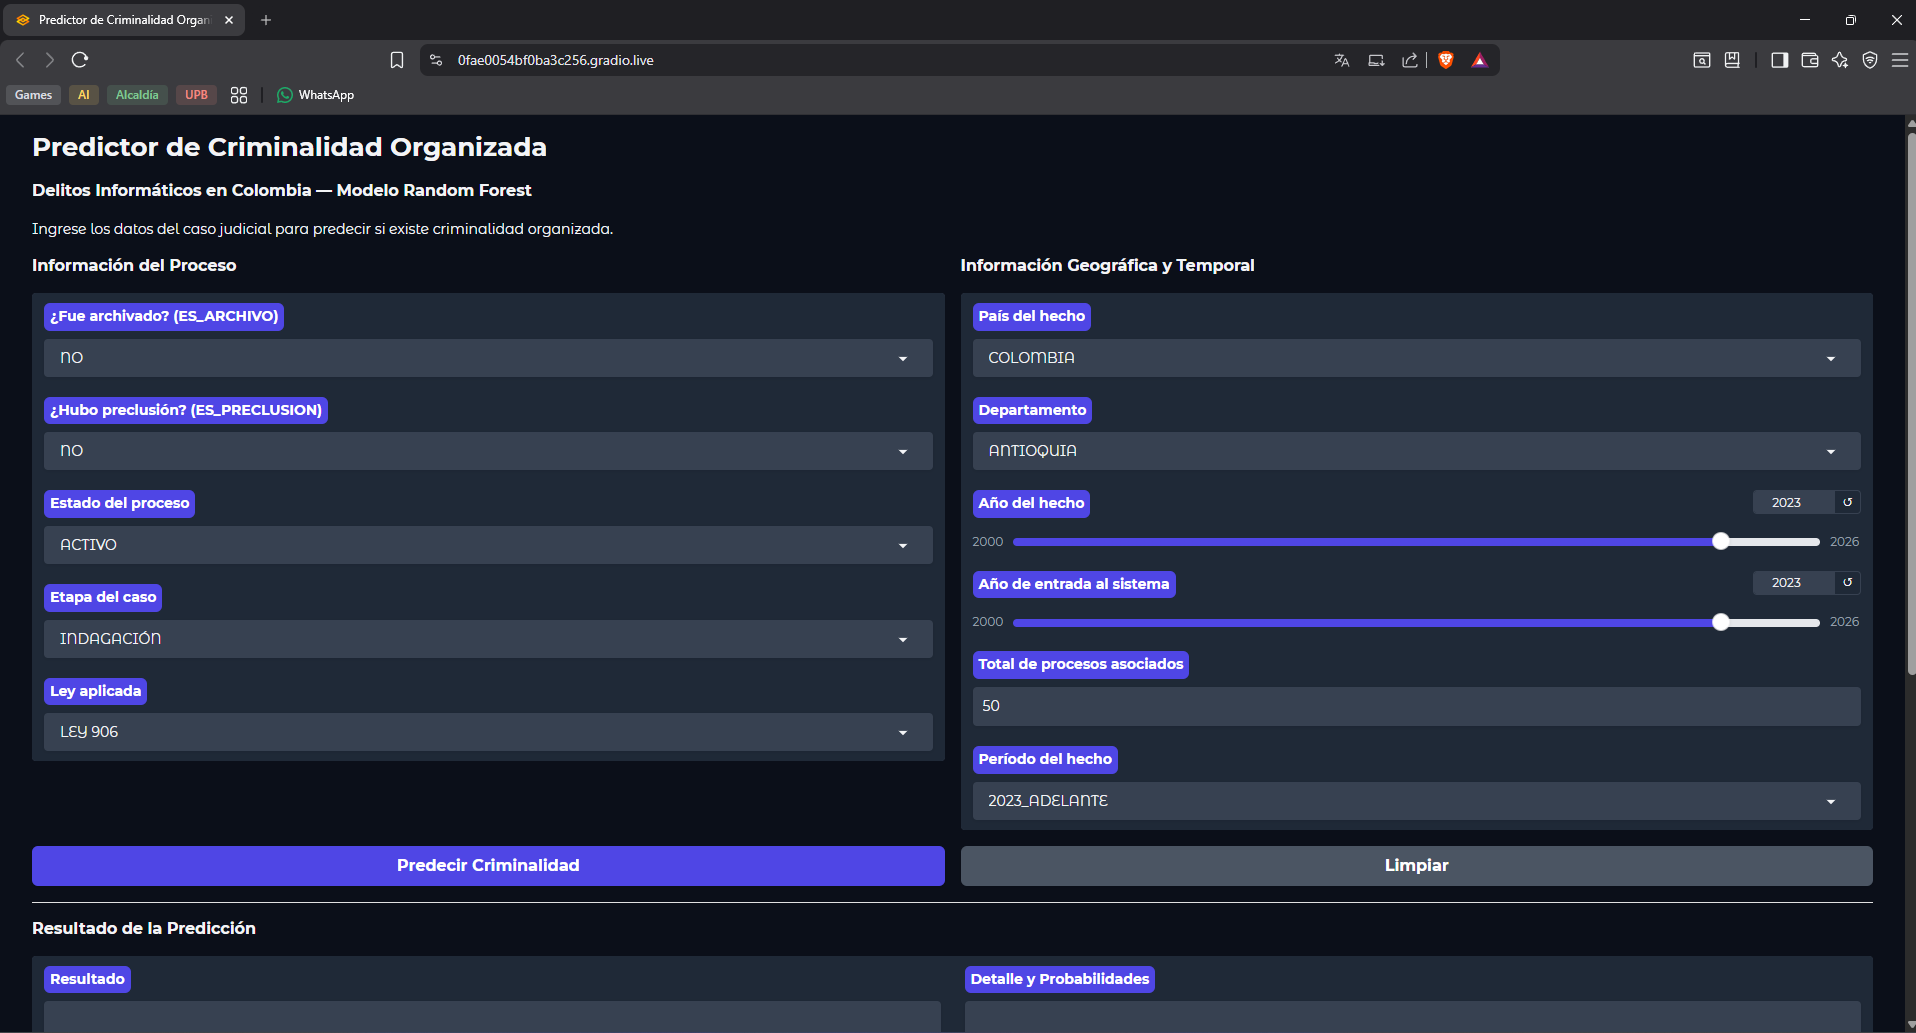
